<a href="https://colab.research.google.com/github/Aritra2k24/Machine-Learning-Fundamentals/blob/main/Ml1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
sns.set_theme(style = 'white')
print('all libraries are imported successfully')

all libraries are imported successfully


In [ ]:
dummy_data = pd.DataFrame({
    'Age':[25,30,np.nan,22,35],
    'Salary':[50000,60000,55000,np.nan,70000],
    'Bought_Product':[1,0,1,0,1]
})
print("messy data")
print(dummy_data)
## cleaning the data ##
dummy_data['Age'] = dummy_data['Age'].fillna(dummy_data['Age'].mean())
dummy_data['Salary'] = dummy_data['Salary'].fillna(0)
print('cleaned data')
print(dummy_data)
X_dummy = dummy_data[['Age','Salary']]
Y_dummy = dummy_data['Bought_Product']
X_dummy_train, X_dummy_test, Y_dummy_train, Y_dummy_test = train_test_split(X_dummy,Y_dummy,test_size=0.2, random_state=42)
print(len(X_dummy_train))
print(len(X_dummy_test))


messy data
    Age   Salary  Bought_Product
0  25.0  50000.0               1
1  30.0  60000.0               0
2   NaN  55000.0               1
3  22.0      NaN               0
4  35.0  70000.0               1
cleaned data
    Age   Salary  Bought_Product
0  25.0  50000.0               1
1  30.0  60000.0               0
2  28.0  55000.0               1
3  22.0      0.0               0
4  35.0  70000.0               1
4
1


In [ ]:
texts = [
    "I love machine learning",
    "I love to code in Python",
    "Machine Learning is fun"
]

vectorizer = CountVectorizer()
text_numbers = vectorizer.fit_transform(texts)
print("the tokens of the text")
print(vectorizer.get_feature_names_out())
print(text_numbers)
print(text_numbers.toarray())

the tokens of the text
['code' 'fun' 'in' 'is' 'learning' 'love' 'machine' 'python' 'to']
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 12 stored elements and shape (3, 9)>
  Coords	Values
  (0, 5)	1
  (0, 6)	1
  (0, 4)	1
  (1, 5)	1
  (1, 8)	1
  (1, 0)	1
  (1, 2)	1
  (1, 7)	1
  (2, 6)	1
  (2, 4)	1
  (2, 3)	1
  (2, 1)	1
[[0 0 0 0 1 1 1 0 0]
 [1 0 1 0 0 1 0 1 1]
 [0 1 0 1 1 0 1 0 0]]


### How `CountVectorizer` Works

`CountVectorizer` is a key tool in Natural Language Processing (NLP) used to convert text collections into a matrix of token counts. Here is a step-by-step breakdown of how it processed your `texts`:

#### 1. Tokenization and Lowercasing
First, `CountVectorizer` converts all text to lowercase and splits the sentences into individual words (tokens), ignoring punctuation by default.
* `"I love machine learning"` $\rightarrow$ `['i', 'love', 'machine', 'learning']`
* `"I love to code in Python"` $\rightarrow$ `['i', 'love', 'to', 'code', 'in', 'python']`
* `"Machine Learning is fun"` $\rightarrow$ `['machine', 'learning', 'is', 'fun']`

#### 2. Building the Vocabulary
It identifies all unique words across all documents and sorts them alphabetically. It also discards single-character words (like `'i'`) by default, as the default token pattern requires words to have at least 2 characters. This results in your vocabulary:

```python
['code', 'fun', 'in', 'is', 'learning', 'love', 'machine', 'python', 'to']
```

We can map each unique word to an index:
* `code`: 0
* `fun`: 1
* `in`: 2
* `is`: 3
* `learning`: 4
* `love`: 5
* `machine`: 6
* `python`: 7
* `to`: 8

#### 3. Vectorization (Counting)
Finally, it counts the occurrences of each vocabulary word in each document, generating a dense representation like this:

| Document | code (0) | fun (1) | in (2) | is (3) | learning (4) | love (5) | machine (6) | python (7) | to (8) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **0**: "I love machine..." | 0 | 0 | 0 | 0 | **1** | **1** | **1** | 0 | 0 |
| **1**: "I love to code..." | **1** | 0 | **1** | 0 | 0 | **1** | 0 | **1** | **1** |
| **2**: "Machine Learning..."| 0 | **1** | 0 | **1** | **1** | 0 | **1** | 0 | 0 |

#### 4. Sparse Matrix Representation
Because real-world text datasets contain thousands of words, most entries in this matrix would be `0`. To save memory, `CountVectorizer` returns a **Compressed Sparse Row (CSR) matrix**, which only stores the locations and values of the non-zero elements. That is why your output printed coordinate-value pairs like `(0, 5)  1` (meaning Document `0`, vocabulary index `5` (`love`) occurs `1` time).

### Understanding `fit_transform()`

The method `fit_transform(raw_documents)` performs two main steps in a single, optimized call:

#### 1. The `fit` step
In this step, the vectorizer **learns the vocabulary** of the training data.
* It scans all the documents provided in `texts`.
* It extracts all unique, valid tokens (words).
* It sorts them alphabetically and assigns each one a unique integer index (as seen in `get_feature_names_out()`).

#### 2. The `transform` step
In this step, the vectorizer **converts the documents into vectors** based on the vocabulary learned during the `fit` step.
* It counts how many times each vocabulary word appears in each document.
* It constructs the final numerical matrix (the sparse CSR matrix).

---

### Why use `fit_transform()` instead of doing them separately?

Using `fit_transform()` on your training data is highly efficient. However, when working with new or test data later, you should **only** use `.transform()`.

Here is how they are typically used in machine learning workflows:

```python
# 1. Learn vocabulary AND extract features from training data
X_train_counts = vectorizer.fit_transform(X_train)

# 2. Extract features from new/test data using the EXACT same vocabulary
X_test_counts = vectorizer.transform(X_test)
```
*Note: If you were to use `fit_transform()` on your test data, it would learn a completely new vocabulary with different word-to-index mappings, making your model's predictions incorrect.*

### Understanding the Printed Output of `text_numbers`

When you ran `print(text_numbers)`, Python displayed this:

```text
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 12 stored elements and shape (3, 9)>
  Coords	Values
  (0, 5)	1
  (0, 6)	1
  (0, 4)	1
  (1, 5)	1
  ...
```

Here is how to decode this output step-by-step:

#### 1. Header Information
* **`shape (3, 9)`**: This indicates your dataset has **3 rows** (for your 3 text documents) and **9 columns** (one column for each unique word in the vocabulary).
* **`12 stored elements`**: This means there are exactly 12 non-zero word counts across all 3 documents. Instead of storing all 27 entries ($3 \times 9$), the computer only stores these 12 values to save memory.

#### 2. Reading the Coordinates `(row, column)   value`
Each line lists a position in the matrix as `(row_index, vocabulary_index)` followed by the count of that word in that document:

* **`(0, 5)    1`**
  * **`0`**: Document index 0 (`"I love machine learning"`)
  * **`5`**: Vocabulary index 5 (`'love'`)
  * **`1`**: Occurs 1 time.

* **`(0, 6)    1`**
  * **`0`**: Document index 0
  * **`6`**: Vocabulary index 6 (`'machine'`)
  * **`1`**: Occurs 1 time.

* **`(0, 4)    1`**
  * **`0`**: Document index 0
  * **`4`**: Vocabulary index 4 (`'learning'`)
  * **`1`**: Occurs 1 time.

Notice that words not in Document 0 (like `'code'`, index 0, or `'fun'`, index 1) are not printed because their value is `0`.

In [ ]:
toy_texts = [
    "The Dog is barking",
    "The Cat is meowing",
    "The Dog and The Cat"
]
tfidf_toy = TfidfVectorizer()
text_numbers = tfidf_toy.fit_transform(toy_texts)
tfidf_frame = pd.DataFrame(text_numbers.toarray(),columns=tfidf_toy.get_feature_names_out())
print(tfidf_frame)
display(tfidf_frame)


        and   barking       cat       dog        is   meowing       the
0  0.000000  0.631745  0.000000  0.480458  0.480458  0.000000  0.373119
1  0.000000  0.000000  0.480458  0.000000  0.480458  0.631745  0.373119
2  0.530587  0.000000  0.403525  0.403525  0.000000  0.000000  0.626747


,and,barking,cat,dog,is,meowing,the
0,0.000000,0.631745,0.000000,0.480458,0.480458,0.000000,0.373119
1,0.000000,0.000000,0.480458,0.000000,0.480458,0.631745,0.373119
2,0.530587,0.000000,0.403525,0.403525,0.000000,0.000000,0.626747


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


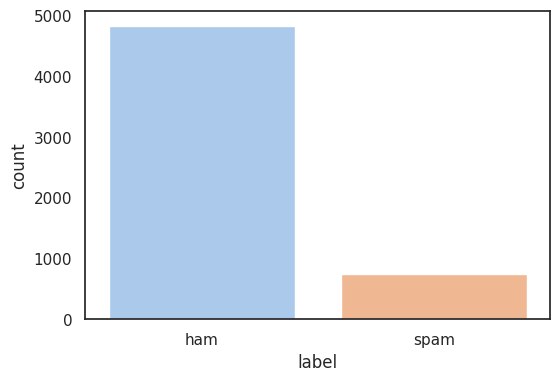

In [ ]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url,sep = '\t',names = ['label','message'])
display(df)
df['label_num'] = df['label'].map({"ham":0,"spam":1})
df
plt.figure(figsize=(6,4))
sns.countplot(df,x= 'label',hue = 'label',palette = 'pastel')
plt.show()

In [ ]:
X = df['message']
Y = df['label_num']
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.2, random_state= 42)
tfidf = TfidfVectorizer(stop_words="english")
X_train_transformed = tfidf.fit_transform(X_train)
X_test_transformed = tfidf.transform(X_test)
print(X_train_transformed.shape)

(4457, 7441)


In [ ]:
model = MultinomialNB()
model.fit(X_train_transformed,Y_train)
print("model training complete")

model training complete


In [ ]:
def testmessages(message_list):
  numbers = tfidf.transform(message_list)
  preds = model.predict(numbers)
  probs = model.predict_proba(numbers)
  for message, pred, prob in zip(message_list, preds, probs):
    label = "Spam" if pred == 1 else "Ham"
    print(message)
    print(f"label:{label} with cofidence:{round(prob[pred]*100,2)}")

my_messages = [
    "Hey bro, are we still meeting for pizza tonight at 8?",
    "CONGRATULATIONS! You have won a $1000 Walmart Gift Card. Click here to claim your prize now!",
    "Urgent! Please call customer service immediately regarding your recent bank transaction."
]

testmessages(my_messages)

Hey bro, are we still meeting for pizza tonight at 8?
label:Ham with cofidence:99.46
CONGRATULATIONS! You have won a $1000 Walmart Gift Card. Click here to claim your prize now!
label:Spam with cofidence:87.65
Urgent! Please call customer service immediately regarding your recent bank transaction.
label:Spam with cofidence:56.55


In [ ]:
predictions = model.predict(X_test_transformed)
accuracy = accuracy_score(predictions, Y_test)
classifications_report = classification_report(Y_test,predictions,target_names = ['Ham','Spam'])
print(accuracy,'\n', classifications_report)

0.97847533632287 
               precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       1.00      0.84      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



confusion matrix


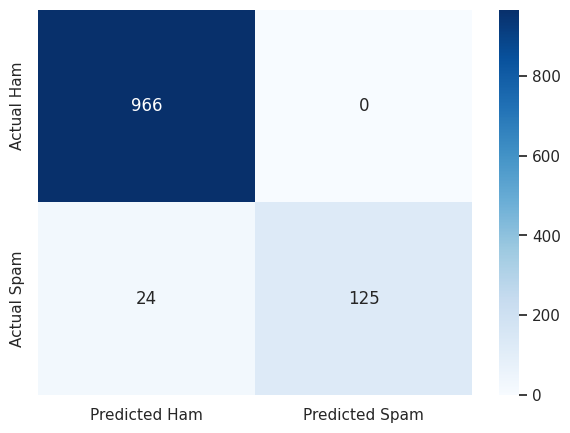

In [ ]:
cm = confusion_matrix(Y_test, predictions)
plt.figure(figsize=(7,5))
sns.heatmap(cm,annot = True,fmt = 'd',cmap= 'Blues',
xticklabels = ['Predicted Ham','Predicted Spam'],
            yticklabels = ['Actual Ham','Actual Spam'])
print("confusion matrix")
plt.show()

In [ ]:
# 1. Create the new model
lr_model = LogisticRegression()

# 2. Train it on the exact same data
lr_model.fit(X_train_transformed, Y_train)

# 3. Make predictions and evaluate
lr_preds = lr_model.predict(X_test_transformed)

print("Logistic Regression Accuracy:", accuracy_score(Y_test, lr_preds) * 100, "%")
print("\nClassification Report:")
print(classification_report(Y_test, lr_preds, target_names=['Ham', 'Spam']))

Logistic Regression Accuracy: 96.95067264573991 %

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115

